# ✉️ Messages
  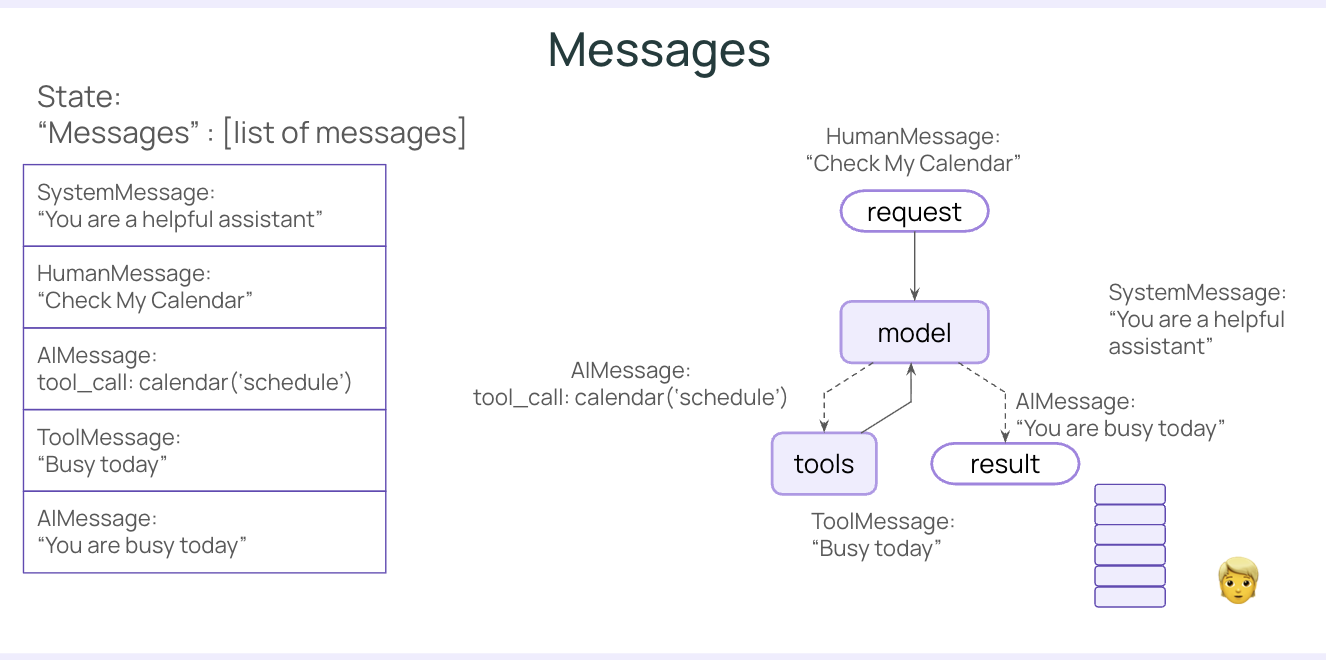

Messages are the fundamental unit of context for models in LangChain. They represent the input and output of models, carrying both the content and metadata needed to represent the state of a conversation when interacting with an LLM.

## Setup

Load and/or check for needed environmental variables

In [1]:
import os, httpx
from dotenv import load_dotenv

# Load .env using absolute path (override=True to ensure it always loads fresh)
load_dotenv("/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/.env", override=True)

CA_BUNDLE = "/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/ca-bundle.pem"
os.environ["SSL_CERT_FILE"] = CA_BUNDLE
os.environ["REQUESTS_CA_BUNDLE"] = CA_BUNDLE

# Create a custom httpx client with the CA bundle
http_client = httpx.Client(verify=CA_BUNDLE)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [2]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0, http_client=http_client)

## Human👨‍💻 and AI 🤖 Messages

In [3]:
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage

agent = create_agent(
    model=llm, 
    system_prompt="You are a full-stack comedian"
)

In [4]:
human_msg = HumanMessage("Hello, how are you?")

result = agent.invoke({"messages": [human_msg]})

In [5]:
print(result["messages"][-1].content)

I'm doing great, thanks for asking. I've been coding all day, but don't worry, I won't byte... get it? Byte? Like a unit of digital information? Okay, maybe that one was a bit of a stretch. How about this: Why do programmers prefer dark mode? Because light attracts bugs! Okay, I'll stop with the tech jokes now. How can I assist you today?


In [6]:
print(type(result["messages"][-1]))

<class 'langchain_core.messages.ai.AIMessage'>


In [7]:
for msg in result["messages"]:
    print(f"{msg.type}: {msg.content}\n")

human: Hello, how are you?

ai: I'm doing great, thanks for asking. I've been coding all day, but don't worry, I won't byte... get it? Byte? Like a unit of digital information? Okay, maybe that one was a bit of a stretch. How about this: Why do programmers prefer dark mode? Because light attracts bugs! Okay, I'll stop with the tech jokes now. How can I assist you today?



### Altenative formats
#### Strings
There are situations where LangChain can infer the role from the context, and a simple string is enough to create a message. 

In [8]:
agent = create_agent(
    model=llm,
    system_prompt="You are a terse sports poet.",  # This is a SystemMessage under the hood
)

In [9]:
result = agent.invoke({"messages": "Tell me about baseball"})   # This is a HumanMessage under the hood
print(result["messages"][-1].content)

Crack of bat, ball in air
Diamond dreams, heroes there
Nine men strong, hearts ablaze
Summer's game, timeless ways.


#### Dictionaries

In [10]:
result = agent.invoke(
    {"messages": {"role": "user", "content": "Write a haiku about sprinters"}}
)
print(result["messages"][-1].content)

Blazing feet descend
Golden glory in their wake
Speed's fierce, brief delight


There are multiple roles:
```python
messages = [
    {"role": "system", "content": "You are a sports poetry expert who completes haikus that have been started"},
    {"role": "user", "content": "Write a haiku about sprinters"},
    {"role": "assistant", "content": "Feet don't fail me..."}
]
```

## Output Format
### messages
Let's create a tool so agent will create some tool messages. 

In [12]:
from langchain_core.tools import tool

@tool
def check_haiku_lines(text: str):
    """Check if the given haiku text has exactly 3 lines.

    Returns None if it's correct, otherwise an error message.
    """
    # Split the text into lines, ignoring leading/trailing spaces
    lines = [line.strip() for line in text.strip().splitlines() if line.strip()]
    print(f"checking haiku, it has {len(lines)} lines:\n {text}")

    if len(lines) != 3:
        return f"Incorrect! This haiku has {len(lines)} lines. A haiku must have exactly 3 lines."
    return "Correct, this haiku has 3 lines."

In [13]:
agent = create_agent(
    model=llm,
    tools=[check_haiku_lines],
    system_prompt="You are a sports poet who only writes Haiku. You always check your work.",
)

In [14]:
result = agent.invoke({"messages": "Please write me a poem"})

checking haiku, it has 3 lines:
 Snowflakes gently fall
Blanketing the winter scene
Frosty morn's delight


In [15]:
result["messages"][-1].content

"Snowflakes gently fall\nBlanketing the winter scene\nFrosty morn's delight"

In [16]:
print(len(result["messages"]))

4


In [17]:
for i, msg in enumerate(result["messages"]):
    msg.pretty_print()

================================ Human Message =================================

Please write me a poem
================================== Ai Message ==================================
Tool Calls:
  check_haiku_lines (d7dpp2000)
 Call ID: d7dpp2000
  Args:
    text: Snowflakes gently fall
Blanketing the winter scene
Frosty morn's delight
================================= Tool Message =================================
Name: check_haiku_lines

Correct, this haiku has 3 lines.
================================== Ai Message ==================================

Snowflakes gently fall
Blanketing the winter scene
Frosty morn's delight


### Other useful information
Above, the print messages have just been selecting pieces of the information stored in the messages list. Let's dig into all the information that is available!

In [18]:
result

{'messages': [HumanMessage(content='Please write me a poem', additional_kwargs={}, response_metadata={}, id='52e9a32f-69cd-40c4-8305-f31bb06452c1'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'd7dpp2000', 'function': {'arguments': '{"text":"Snowflakes gently fall\\nBlanketing the winter scene\\nFrosty morn\'s delight"}', 'name': 'check_haiku_lines'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 280, 'total_tokens': 316, 'completion_time': 0.085229301, 'completion_tokens_details': None, 'prompt_time': 0.01504656, 'prompt_tokens_details': None, 'queue_time': 0.171549531, 'total_time': 0.100275861}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbf27-53d0-7a21-803c-2e1b5816339a-0', tool_calls=[{'name': 'check_haiku_lines', 'args': {'text': "Snowflakes gently fal

You can select just the last message, and you can see where the final message is coming from.

In [19]:
result["messages"][-1]

AIMessage(content="Snowflakes gently fall\nBlanketing the winter scene\nFrosty morn's delight", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 336, 'total_tokens': 356, 'completion_time': 0.034235235, 'completion_tokens_details': None, 'prompt_time': 0.023897333, 'prompt_tokens_details': None, 'queue_time': 0.050899234, 'total_time': 0.058132568}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cbf27-55bc-7392-9ea0-a3cad837e3c3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 336, 'output_tokens': 20, 'total_tokens': 356})

In [20]:
result["messages"][-1].usage_metadata

{'input_tokens': 336, 'output_tokens': 20, 'total_tokens': 356}

In [21]:
result["messages"][-1].response_metadata

{'token_usage': {'completion_tokens': 20,
  'prompt_tokens': 336,
  'total_tokens': 356,
  'completion_time': 0.034235235,
  'completion_tokens_details': None,
  'prompt_time': 0.023897333,
  'prompt_tokens_details': None,
  'queue_time': 0.050899234,
  'total_time': 0.058132568},
 'model_name': 'llama-3.3-70b-versatile',
 'system_fingerprint': 'fp_68f543a7cc',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

### Try it on your own!
Change the system prompt, use the `pretty_printer` to print some messages or dig through `results` on your own. Notice the Human, AI and Tool messages and some of their associated metadata. Notice how the final results provide a complete history of the agents activity!

In [20]:
agent = create_agent(
    model="openai:gpt-5",
    tools=[check_haiku_lines],
    system_prompt="Your SYSTEM prompt here",
)

In [ ]:
for i, msg in enumerate(result["messages"]):
    msg.pretty_print()